<p align="center">
  <img src="https://images.unsplash.com/photo-1551288049-bebda4e38f71?auto=format&fit=crop&w=1600&q=85"
       width="100%" alt="Data Cleaning and Exploratory Data Analysis">
</p>

<h1 align="center">🧹 Data Cleaning and Exploratory Data Analysis</h1>

<p align="center">
  <b>Notebook 02 — Data Preparation & Exploratory Analysis</b><br>
  Transforming Raw Web Data into Analysis-Ready Data
</p>

---

## 📌 Project Overview

This notebook represents the **second stage** of the Web Intelligence and NLP-Based Sentiment Analytics project.

The raw dataset collected during the web-scraping stage is inspected, cleaned, validated, and explored to understand its structure, quality, text characteristics, and basic patterns before NLP preprocessing.

### 🎯 Objective

The objective is to:

- Load the raw scraped dataset
- Understand its structure and data types
- Identify missing and duplicate records
- Clean textual fields
- Standardize data formats
- Analyze text length and basic distributions
- Explore authors, tags, and other available fields
- Create basic visualizations
- Save the cleaned dataset for NLP preprocessing

### 🔄 Workflow

```text
📦 Raw Data
    ↓
🔍 Inspection
    ↓
❓ Missing Values
    ↓
♻️ Duplicate Detection
    ↓
🧹 Text Cleaning
    ↓
📊 EDA
    ↓
✅ Validation
    ↓
💾 cleaned_data.csv
```

## 📓 Notebook Workflow

```text
01. Import Libraries
02. Load Raw Dataset
03. Dataset Overview
04. Data Structure & Types
05. Missing Value Analysis
06. Duplicate Analysis
07. Data Quality Checks
08. Text Cleaning
09. Text Length Analysis
10. Author Analysis
11. Tag Analysis
12. Date Analysis
13. Rating Analysis
14. Basic Visualizations
15. Final Validation
16. Save Cleaned Dataset
17. Final Summary
```

## 1. Import Libraries

Import the libraries required for data manipulation, text cleaning, statistical analysis, and visualization.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Text Processing
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File & Path Management
from pathlib import Path

# Warning Control
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure Project Paths

Define the project directories and input/output dataset paths.

The raw dataset generated by `01_Web_Scraping.ipynb` will be used as the input for this notebook.

In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

RAW_FILE = RAW_DATA_DIR / "scraped_quotes.csv"
CLEANED_FILE = PROCESSED_DATA_DIR / "cleaned_quotes.csv"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw dataset    : {RAW_FILE}")
print(f"Cleaned output : {CLEANED_FILE}")

Raw dataset    : D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\raw\scraped_quotes.csv
Cleaned output : D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\processed\cleaned_quotes.csv


## 3. Load Raw Dataset

Load the raw dataset produced during the web-scraping stage.

No cleaning is performed at this point. The original data is preserved so that its quality can be assessed before transformation.

In [3]:
# ============================================================
# LOAD RAW DATA
# ============================================================

df = pd.read_csv(RAW_FILE)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape}")

display(df.head())

Dataset loaded successfully.
Shape: (100, 5)


,quote_id,quote_text,author,tags,source_url
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",Marilyn Monroe,"be-yourself, inspirational",https://quotes.toscrape.com/


## 4. Dataset Overview

Begin the analysis by examining the first and last records, dataset dimensions, and column names.

These checks provide an initial understanding of the collected data.

In [4]:
# ============================================================
# BASIC DATA OVERVIEW
# ============================================================

print("First 5 Records")
display(df.head())

print("\nLast 5 Records")
display(df.tail())

print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

print("\nColumn Names")
print(df.columns.tolist())

First 5 Records


,quote_id,quote_text,author,tags,source_url
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",Marilyn Monroe,"be-yourself, inspirational",https://quotes.toscrape.com/



Last 5 Records


,quote_id,quote_text,author,tags,source_url
95,96,“You never really understand a person until you consider things from his point of view... Until you climb inside of his skin and walk around in it.”,Harper Lee,better-life-empathy,https://quotes.toscrape.com/page/10/
96,97,"“You have to write the book that wants to be written. And if the book will be too difficult for grown-ups, then you write it for children.”",Madeleine L'Engle,"books, children, difficult, grown-ups, write, writers, writing",https://quotes.toscrape.com/page/10/
97,98,“Never tell the truth to people who are not worthy of it.”,Mark Twain,truth,https://quotes.toscrape.com/page/10/
98,99,"“A person's a person, no matter how small.”",Dr. Seuss,inspirational,https://quotes.toscrape.com/page/10/
99,100,"“... a mind needs books as a sword needs a whetstone, if it is to keep its edge.”",George R.R. Martin,"books, mind",https://quotes.toscrape.com/page/10/



Rows    : 100
Columns : 5

Column Names
['quote_id', 'quote_text', 'author', 'tags', 'source_url']


## 5. Data Structure & Data Types

Inspect the internal structure of the dataset using `info()` and summarize the data types.

Understanding data types is important before performing transformations or analysis.

In [5]:
# ============================================================
# DATA STRUCTURE
# ============================================================

df.info()

print("\nData Types")
display(df.dtypes.to_frame("dtype"))

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   quote_id    100 non-null    int64
 1   quote_text  100 non-null    str  
 2   author      100 non-null    str  
 3   tags        97 non-null     str  
 4   source_url  100 non-null    str  
dtypes: int64(1), str(4)
memory usage: 23.1 KB

Data Types


,dtype
quote_id,int64
quote_text,str
author,str
tags,str
source_url,str


## 6. Statistical Summary

Generate descriptive statistics for the available numerical columns.

For textual columns, basic descriptive information such as unique values and frequency can be examined separately.

In [6]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
quote_id,100.0,NaN,NaN,NaN,50.5,29.011492,1.0,25.75,50.5,75.25,100.0
quote_text,100,100,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
author,100,50,Albert Einstein,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,97,83,love,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_url,100,10,https://quotes.toscrape.com/,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Missing Value Analysis

Identify missing values in every column.

Missing values are important because incomplete text or metadata can affect downstream NLP and analytical results.

In [7]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

display(missing_summary.sort_values("missing_count", ascending=False))

,missing_count,missing_percentage
tags,3,3.0
quote_id,0,0.0
quote_text,0,0.0
author,0,0.0
source_url,0,0.0


## 8. Duplicate Analysis

Check for completely duplicated rows and duplicated textual records.

Duplicate content can bias frequency-based NLP analysis and should be reviewed before modeling.

In [8]:
# ============================================================
# DUPLICATE ANALYSIS
# ============================================================

total_duplicates = df.duplicated().sum()
text_duplicates = df["quote_text"].duplicated().sum()

print(f"Duplicate rows        : {total_duplicates:,}")
print(f"Duplicate quote text  : {text_duplicates:,}")

Duplicate rows        : 0
Duplicate quote text  : 0


## 9. Data Quality Checks

Review whether important fields contain empty strings or whitespace-only values.

This complements the missing-value analysis because an empty string is not always represented as `NaN`.

In [9]:
# ============================================================
# DATA QUALITY CHECKS
# ============================================================

text_columns = ["quote_text", "author", "tags"]

for column in text_columns:
    empty_count = (
        df[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    print(f"{column:<15}: {empty_count:,} empty values")

quote_text     : 0 empty values
author         : 0 empty values
tags           : 3 empty values


## 10. Text Cleaning

Clean the primary textual field while preserving the original raw dataset.

The cleaning process removes unnecessary whitespace and normalizes common text noise without applying NLP-specific transformations such as stopword removal or lemmatization.

Those operations will be performed in the dedicated NLP preprocessing notebook.

In [10]:
# ============================================================
# TEXT CLEANING
# ============================================================

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


df["quote_text"] = df["quote_text"].apply(clean_text)
df["author"] = df["author"].apply(clean_text)
df["tags"] = df["tags"].apply(clean_text)

print("Text cleaning completed.")
display(df[["quote_text", "author", "tags"]].head())

Text cleaning completed.


,quote_text,author,tags
0,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",Marilyn Monroe,"be-yourself, inspirational"


## 11. Remove Invalid Records

Remove records where the primary text field is empty after cleaning.

A text record without usable textual content cannot contribute to the NLP pipeline.

In [11]:
# ============================================================
# REMOVE INVALID TEXT RECORDS
# ============================================================

before_rows = len(df)

df = df[df["quote_text"].str.len() > 0].copy()

after_rows = len(df)

print(f"Rows before cleaning : {before_rows:,}")
print(f"Rows after cleaning  : {after_rows:,}")
print(f"Rows removed         : {before_rows - after_rows:,}")

Rows before cleaning : 100
Rows after cleaning  : 100
Rows removed         : 0


## 12. Remove Duplicate Records

Remove exact duplicate records based on the primary quote text.

This prevents repeated textual content from disproportionately influencing later NLP analysis.

In [12]:
# ============================================================
# REMOVE DUPLICATES
# ============================================================

before_duplicates = len(df)

df = df.drop_duplicates(
    subset=["quote_text"],
    keep="first"
).copy()

after_duplicates = len(df)

print(f"Rows before deduplication : {before_duplicates:,}")
print(f"Rows after deduplication  : {after_duplicates:,}")
print(f"Duplicates removed       : {before_duplicates - after_duplicates:,}")

Rows before deduplication : 100
Rows after deduplication  : 100
Duplicates removed       : 0


## 13. Text Length Analysis

Create a text-length feature to understand the distribution of quote sizes.

This feature will also be useful for detecting unusually short or long records.

In [13]:
# ============================================================
# TEXT LENGTH ANALYSIS
# ============================================================

df["text_length"] = df["quote_text"].str.len()

display(
    df["text_length"]
    .describe()
    .to_frame("text_length")
)

,text_length
count,100.000000
mean,122.270000
std,133.747376
min,34.000000
25%,66.500000
50%,86.000000
75%,125.000000
max,1084.000000


## 14. Text Length Distribution

Visualize the distribution of textual content length.

The distribution helps identify whether the dataset contains mostly short statements or longer textual records.

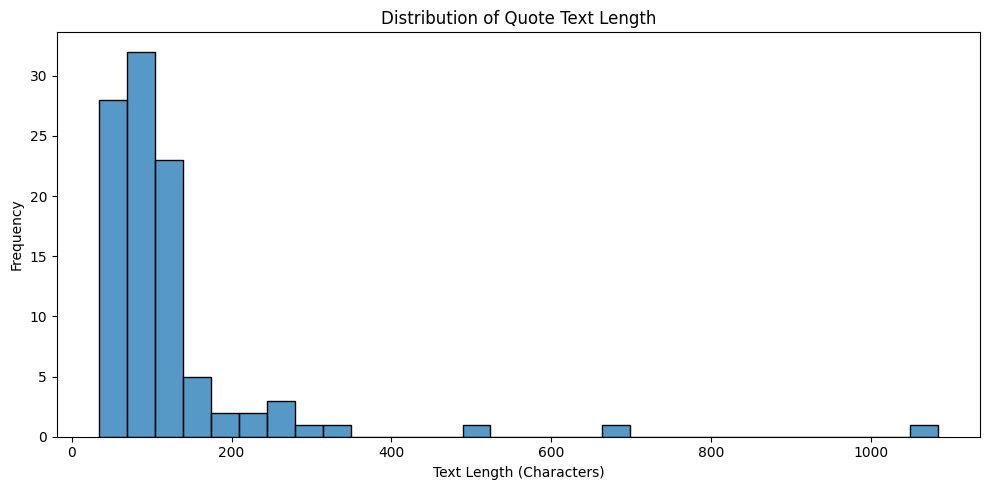

In [14]:
# ============================================================
# TEXT LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="text_length",
    bins=30
)

plt.title("Distribution of Quote Text Length")
plt.xlabel("Text Length (Characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 15. Author Analysis

Analyze the number of unique authors and identify authors with the highest number of collected quotes.

In [15]:
# ============================================================
# AUTHOR ANALYSIS
# ============================================================

print(f"Unique Authors: {df['author'].nunique():,}")

top_authors = (
    df["author"]
    .value_counts()
    .head(10)
    .rename_axis("author")
    .reset_index(name="quote_count")
)

display(top_authors)

Unique Authors: 50


,author,quote_count
0,Albert Einstein,10
1,J.K. Rowling,9
2,Marilyn Monroe,7
3,Dr. Seuss,6
4,Mark Twain,6
5,Jane Austen,5
6,C.S. Lewis,5
7,Bob Marley,3
8,Eleanor Roosevelt,2
9,Ralph Waldo Emerson,2


## 16. Tag Analysis

The source provides tags associated with each quote.

Split the tag strings into individual tags and analyze the most frequently occurring tags.

In [16]:
# ============================================================
# TAG ANALYSIS
# ============================================================

tag_series = (
    df["tags"]
    .fillna("")
    .str.split(", ")
    .explode()
    .str.strip()
)

tag_series = tag_series[tag_series.ne("")]

top_tags = (
    tag_series
    .value_counts()
    .head(15)
    .rename_axis("tag")
    .reset_index(name="count")
)

display(top_tags)

,tag,count
0,love,14
1,inspirational,13
2,life,13
3,humor,12
4,books,11
5,reading,7
6,friendship,5
7,friends,4
8,truth,4
9,simile,3


## 17. Tag Distribution

Visualize the most frequently occurring tags.

This provides a basic view of the themes represented in the scraped dataset.

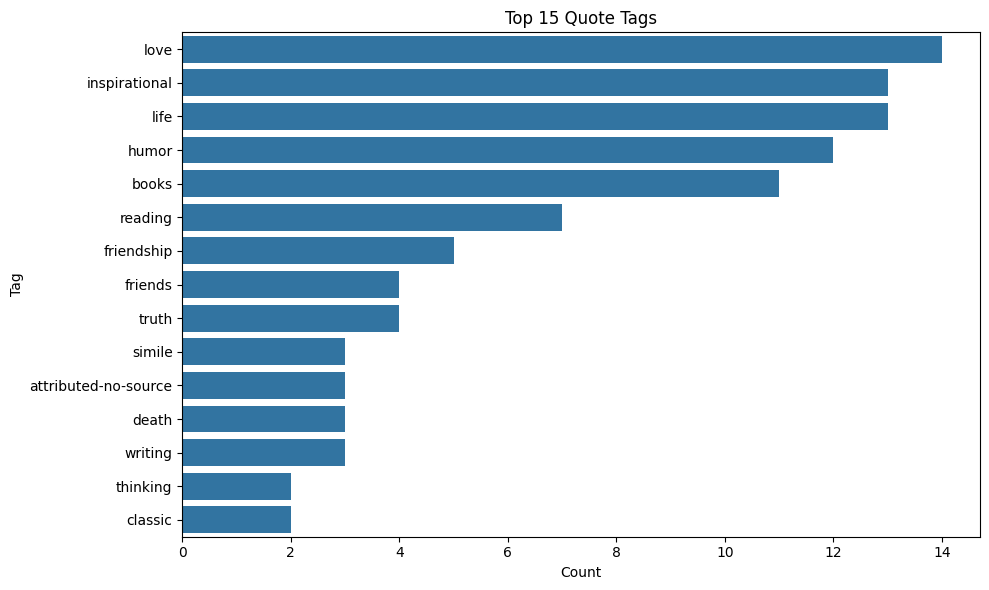

In [17]:
# ============================================================
# TOP TAGS VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_tags,
    x="count",
    y="tag"
)

plt.title("Top 15 Quote Tags")
plt.xlabel("Count")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

## 18. Date Analysis

The current practice source does not provide a meaningful publication date for every quote.

Therefore, date-based analysis is performed only when a valid date column is available.

This conditional approach prevents creating artificial dates or misleading time-series results.

In [18]:
# ============================================================
# DATE ANALYSIS
# ============================================================

date_columns = [
    column for column in df.columns
    if "date" in column.lower()
]

if date_columns:
    date_column = date_columns[0]

    df[date_column] = pd.to_datetime(
        df[date_column],
        errors="coerce"
    )

    print(f"Date column detected: {date_column}")
    display(df[date_column].describe())
else:
    print("No date column is available in the current source.")
    print("Date analysis will be skipped.")

No date column is available in the current source.
Date analysis will be skipped.


## 19. Rating Analysis

The current `Quotes to Scrape` dataset does not provide a numeric rating field.

Therefore, rating distribution analysis is skipped rather than creating artificial ratings.

For a future review-based data source containing ratings, this section can analyze rating frequency and its relationship with sentiment.

In [19]:
# ============================================================
# RATING ANALYSIS
# ============================================================

rating_columns = [
    column for column in df.columns
    if "rating" in column.lower()
]

if rating_columns:
    rating_column = rating_columns[0]

    print(f"Rating column detected: {rating_column}")
    display(df[rating_column].value_counts().sort_index())
else:
    print("No rating column is available in the current source.")
    print("Rating distribution will be skipped.")

No rating column is available in the current source.
Rating distribution will be skipped.


## 20. Final Data Validation

Perform a final quality check after cleaning.

The cleaned dataset should contain usable text, unique quote records, and consistent column values before being saved for downstream NLP processing.

In [20]:
# ============================================================
# FINAL VALIDATION
# ============================================================

print("FINAL DATA VALIDATION")
print("=" * 60)

print(f"Rows              : {len(df):,}")
print(f"Columns           : {df.shape[1]:,}")
print(f"Missing values    : {df.isna().sum().sum():,}")
print(f"Duplicate rows    : {df.duplicated().sum():,}")
print(f"Empty quote text  : {df['quote_text'].eq('').sum():,}")

print("\nColumns:")
print(df.columns.tolist())

FINAL DATA VALIDATION
Rows              : 100
Columns           : 6
Missing values    : 0
Duplicate rows    : 0
Empty quote text  : 0

Columns:
['quote_id', 'quote_text', 'author', 'tags', 'source_url', 'text_length']


## 21. Final Dataset Preview

Review the cleaned dataset before exporting it.

The `text_length` feature is retained because it provides useful descriptive information for the next stages of analysis.

In [21]:
# ============================================================
# CLEANED DATA PREVIEW
# ============================================================

display(df.head(10))

,quote_id,quote_text,author,tags,source_url,text_length
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/,115
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/,85
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/,131
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/,104
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",Marilyn Monroe,"be-yourself, inspirational",https://quotes.toscrape.com/,111
5,6,“Try not to become a man of success. Rather become a man of value.”,Albert Einstein,"adulthood, success, value",https://quotes.toscrape.com/,67
6,7,“It is better to be hated for what you are than to be loved for what you are not.”,André Gide,"life, love",https://quotes.toscrape.com/,82
7,8,"“I have not failed. I've just found 10,000 ways that won't work.”",Thomas A. Edison,"edison, failure, inspirational, paraphrased",https://quotes.toscrape.com/,65
8,9,“A woman is like a tea bag; you never know how strong it is until it's in hot water.”,Eleanor Roosevelt,misattributed-eleanor-roosevelt,https://quotes.toscrape.com/,85
9,10,"“A day without sunshine is like, you know, night.”",Steve Martin,"humor, obvious, simile",https://quotes.toscrape.com/,50


## 22. Save Cleaned Dataset

Save the cleaned dataset to the project's `data/processed/` directory.

The raw dataset remains unchanged, while this file becomes the input for the next NLP preprocessing notebook.

### Output

```text
data/processed/cleaned_quotes.csv
```

In [22]:
# ============================================================
# SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    CLEANED_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Cleaned dataset saved successfully.")
print(f"Output: {CLEANED_FILE}")

Cleaned dataset saved successfully.
Output: D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\processed\cleaned_quotes.csv


## 📊 Final Summary

The raw web dataset has been inspected, cleaned, validated, and explored.

### Completed Tasks

- Loaded raw scraped data
- Inspected dataset structure
- Reviewed data types
- Analyzed missing values
- Detected duplicate records
- Cleaned textual fields
- Removed invalid and duplicate text records
- Created text-length features
- Analyzed authors and tags
- Checked date availability
- Checked rating availability
- Created basic visualizations
- Saved the cleaned dataset

### Output Dataset

```text
data/processed/cleaned_quotes.csv
```

This cleaned dataset is now ready for **NLP preprocessing**.

## 🔗 Notebook Navigation

**Previous:** `01_Web_Scraping.ipynb`

**Current:** `02_Data_Cleaning_and_EDA.ipynb`

**Next:** `03_NLP_Preprocessing.ipynb`

---

### 🚀 Next Stage

The next notebook will transform the cleaned text into **NLP-ready data** using text normalization, tokenization, stopword handling, lemmatization, n-grams, and other preprocessing techniques.